TELECOM CHURN PREDICTION - Ayesha Gupta

Project Objective:
The objective of this project is to predict whether a telecom customer is likely to leave the service(churn) based on customer demographics, account information, and service usage patterns.


In [1]:
# Importing pandas and loading dataset
import pandas as pd

# Loading dataset
df = pd.read_csv('churn.csv')

In [2]:
# Display the first 5 rows
display(df.head())

# Preprocessing: Convert TotalCharges to numeric and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data Structure and Data types

# Shape
print(f"Dataset shape: {df.shape}\n")

# Column Names
print(f"Dataset columns: {df.columns.tolist()}\n")

# Datatypes
print("Dataset data types:\n")
print(df.dtypes)

Dataset shape: (7043, 21)

Dataset columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset data types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [4]:
# Checking missing values
print("\nMissing values per column:\n")
print(df.isnull().sum().sort_values(ascending=False))


Missing values per column:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# Display info()-a concise summary of the DataFrame, including the number of entries, column names, non-null counts, and data types.
print("\nDataFrame Info:\n")
df.info()

# Describe-descriptive statistics of the numerical columns in the DataFrame, such as mean, standard deviation, min, max, and quartiles.
print("\nDataFrame Description (Numerical Columns):\n")
display(df.describe())

print("\nDataFrame Description (Categorical Columns):\n")
display(df.describe(include='object'))


DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000



DataFrame Description (Categorical Columns):



,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


OBSERVATIONS FROM DATASET OVERVIEW

- The dataset contains 7043 rows and 21 columns.
- The target variable is Churn.
- The dataset contains both numerical and categorical features.
- No missing values are present in the dataset.
- This dataset will be used to predict whether a customer is likely to leave the telecom service.

## Exploratory Data Analysis (EDA):-

In [6]:
# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Churn Distribution (Counts):
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Distribution (Percentage):
 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


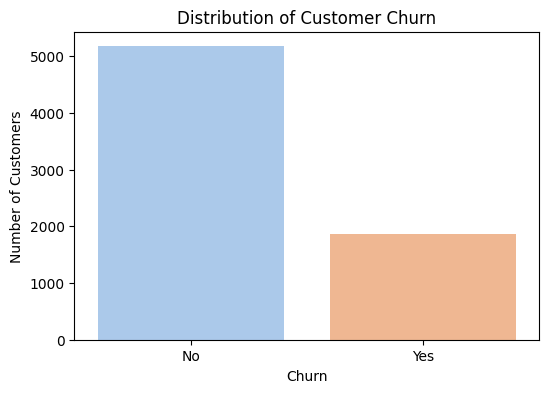

In [7]:
# EDA : 1.Churn Distribution (Counts and Percentage)

# Calculate the counts of 'Churn' values
churn_counts = df['Churn'].value_counts()

# Calculate the percentage of 'Churn' values
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution (Counts):\n", churn_counts)
print("\nChurn Distribution (Percentage):\n", churn_percentage.round(2))

# Plotting the distribution of Churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='pastel', legend=False)
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

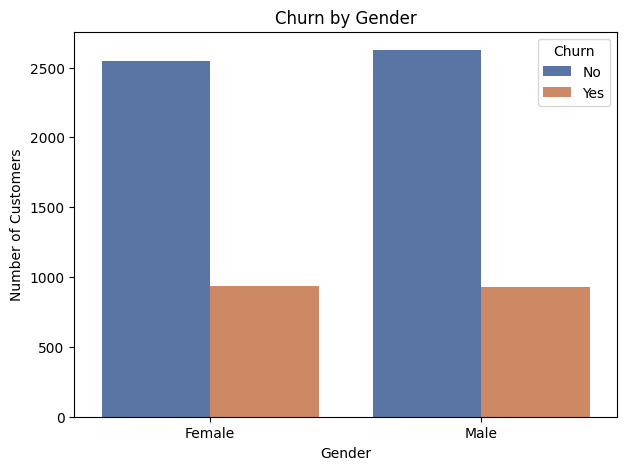

In [8]:
# EDA : 2.Churn Analysis by Gender

# A countplot to show churn based on gender
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='gender', hue='Churn',palette='deep')
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

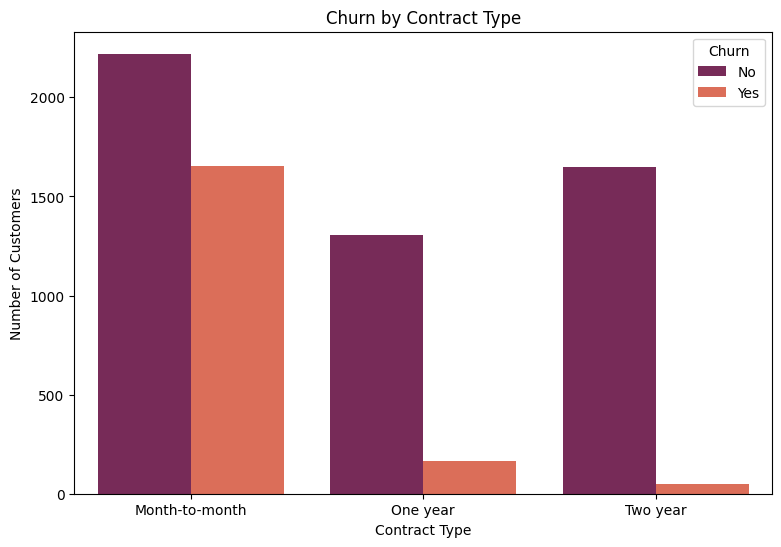

In [9]:
# EDA : 3.Churn Analysis by Contract Type

# A countplot to show churn based on contract type
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='rocket')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

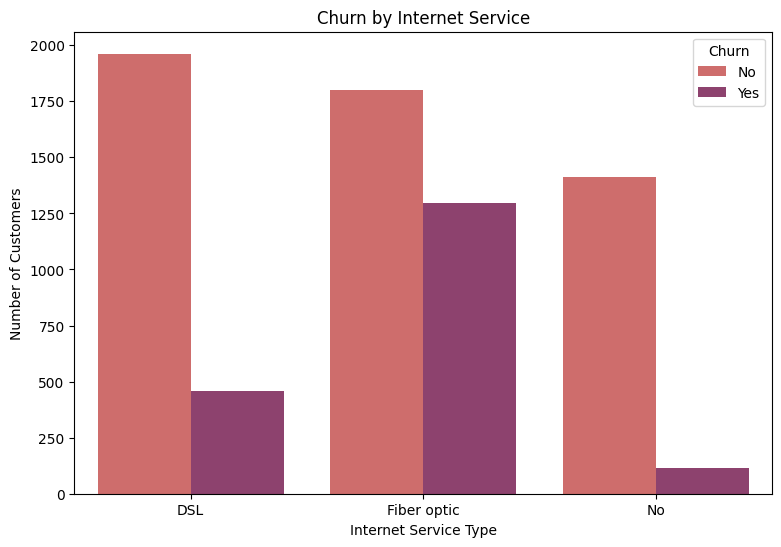

In [10]:
# EDA : 4.Churn Analysis by Internet Service

# A countplot to show churn based on internet service
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='flare')
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.show()

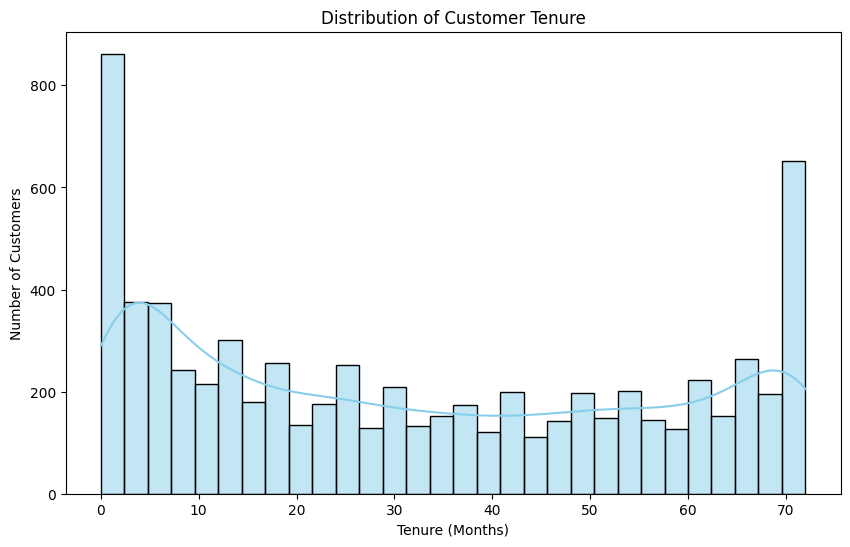

In [11]:
# EDA : 5.Distribution of Tenure

# A histogram to show the distribution of customer tenure
plt.figure(figsize=(10, 6))
sns.histplot(df['tenure'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

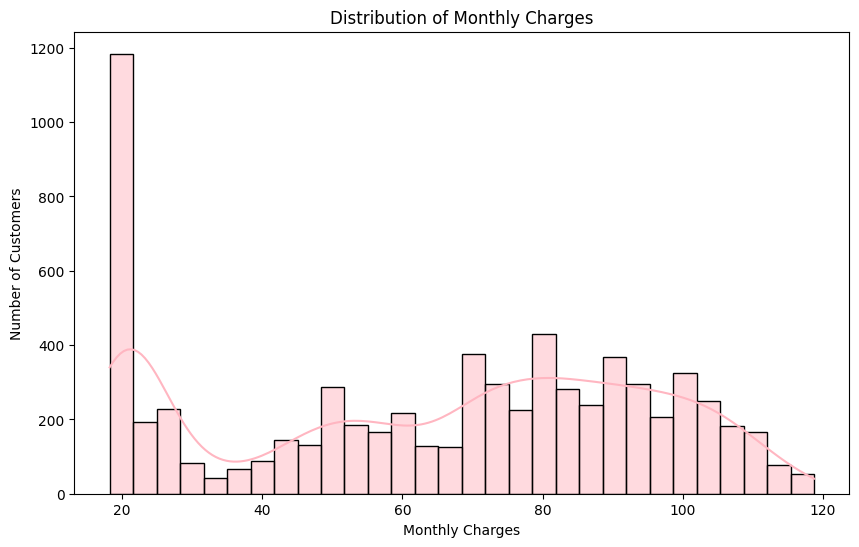

In [12]:
# EDA : 6.Distribution of Monthly Charges

# A histogram to show the distribution of monthly charges
plt.figure(figsize=(10, 6))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='lightpink')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

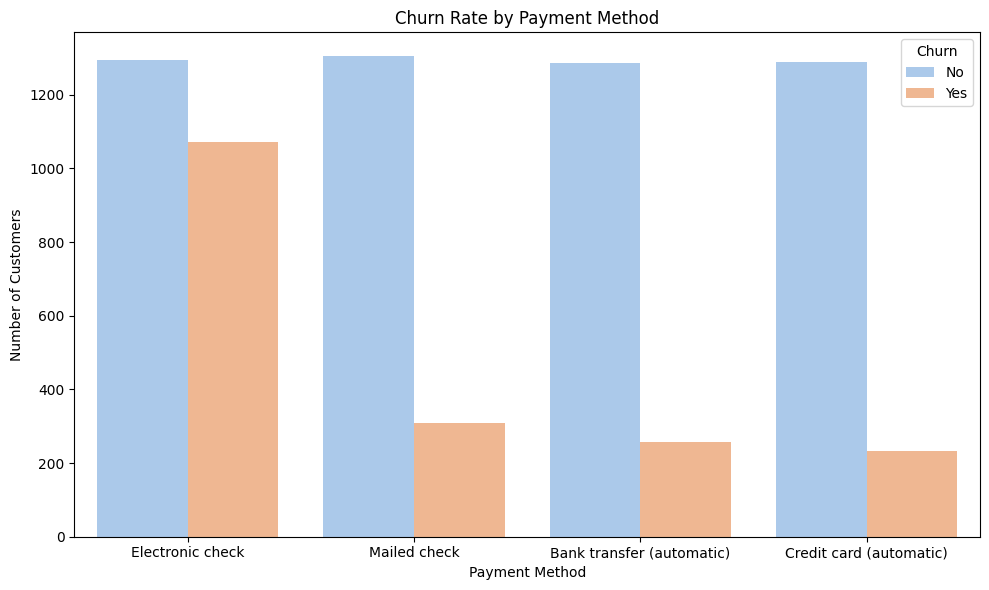

In [13]:
# EDA : 7.PaymentMethod vs Churn

# A countplot showing churn based on payment method
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='pastel')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

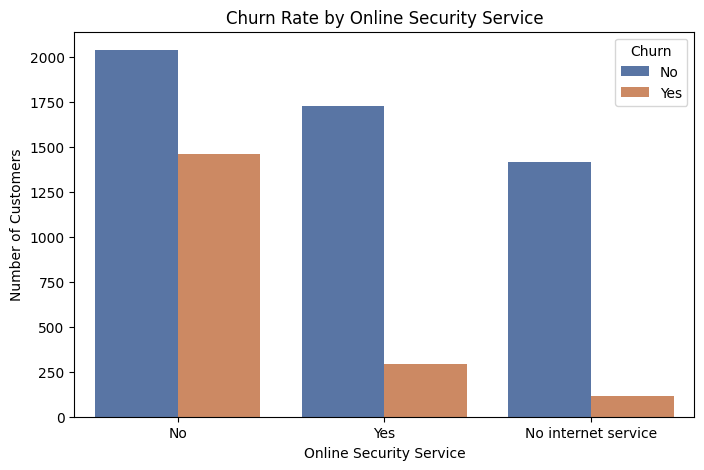

In [14]:
# EDA : 8.OnlineSecurity vs Churn

# A countplot showing churn based on online security service
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='OnlineSecurity', hue='Churn', palette='deep')
plt.title('Churn Rate by Online Security Service')
plt.xlabel('Online Security Service')
plt.ylabel('Number of Customers')
plt.show()

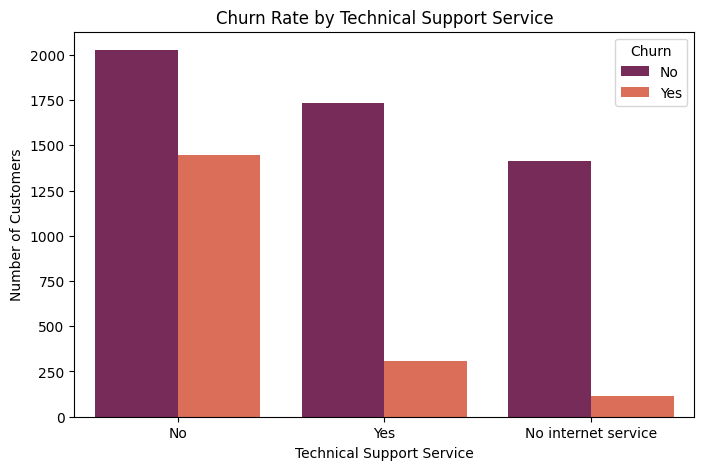

In [15]:
# EDA : 9.TechSupport vs Churn

# A countplot showing churn based on technical support service
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='TechSupport', hue='Churn', palette='rocket')
plt.title('Churn Rate by Technical Support Service')
plt.xlabel('Technical Support Service')
plt.ylabel('Number of Customers')
plt.show()

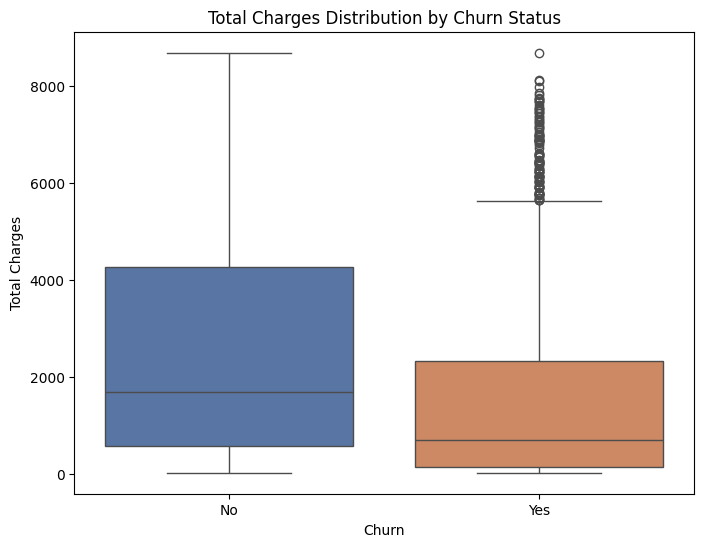

In [16]:
# EDA : 10.TotalCharges vs Churn

# A boxplot showing total charges distribution by churn status
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='TotalCharges', hue='Churn', palette='deep', legend=False)
plt.title('Total Charges Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Total Charges')
plt.show()

After performing Exploratory Data Analysis on the Telco Customer Churn dataset, several key patterns were observed:

1. Contract type is one of the most important factors affecting churn. Customers with month-to-month contracts are significantly more likely to leave compared to longer-term contracts.

2. Payment method also influences churn. Customers using electronic check show higher churn rates compared to other payment methods.

3. Customer tenure has a strong relationship with churn. Newer customers (low tenure) are more likely to leave, while long-term customers tend to stay.

4. Service-related features such as Online Security and Tech Support play an important role. Customers without these services are more likely to churn.

5. Pricing shows some impact on churn. Customers with higher monthly charges tend to churn slightly more.

6. Total charges reflect customer lifetime value. Customers who churn generally have lower total charges, indicating shorter customer lifespan.

Overall, churn is mainly driven by contract type, tenure, payment method, and service usage patterns, while demographic features like gender have minimal impact on churn behavior.

In [17]:
# Create a clean copy of the dataset for preprocessing.
df_clean = df.copy()
# Drop 'customerID' as it's a unique identifier and not a predictive feature.
df_clean = df_clean.drop('customerID', axis=1)

In [18]:
display(df_clean.isnull().sum())

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [19]:
# Convert all categorical (text) columns into numerical format using one-hot encoding.
df_encoded = pd.get_dummies(df_clean, drop_first=True)

In [20]:
df_encoded.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')

In [21]:
# Features (input data)
X = df_encoded.drop('Churn_Yes', axis=1)

# Target (what we want to predict)
y = df_encoded['Churn_Yes']

## Train-Test Split (Data Preparation)

In [22]:
# Step 1: Split dataset into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
# Install imbalanced-learn if not already installed
!pip install imbalanced-learn

In [24]:
# Handle Imbalanced Data using SMOTE
from imblearn.over_sampling import SMOTE

smt = SMOTE(random_state=42)
X_train_smote, y_train_smote = smt.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"SMOTE training set shape: {X_train_smote.shape}, {y_train_smote.shape}")
print(f"Class distribution after SMOTE: {y_train_smote.value_counts()}")

Original training set shape: (5634, 30), (5634,)
SMOTE training set shape: (8276, 30), (8276,)
Class distribution after SMOTE: Churn_Yes
False    4138
True     4138
Name: count, dtype: int64


## Feature Scaling (Standardization)

In [25]:
# Step 2: Standardize features to bring all variables to same scale
# This helps Logistic Regression converge faster and perform better
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

## Model Training (Logistic Regression)

In [26]:
# Step 3: Train Logistic Regression model on scaled training data
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42) # Added random_state
model.fit(X_train_scaled, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

## MODEL TRAINING SUMMARY

We trained a Logistic Regression model using the preprocessed and scaled training data.

* The dataset was divided into training (80%) and testing (20%) sets.
* To address class imbalance, SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data before model training.
* Feature scaling was performed using StandardScaler to ensure all variables were on a similar scale, helping the model perform more effectively.
* Logistic Regression was used as the classification model to predict customer churn based on customer demographics, account information, and service usage patterns.

This trained model learns the relationship between customer characteristics and churn behavior, allowing it to predict whether a customer is likely to leave the telecom service.


## MODEL EVALUATION:-


In [27]:
# Step 1: Predictions
y_pred = model.predict(X_test_scaled)

In [28]:
# Step 2: Accuracy Score
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7977288857345636


In [29]:
# Step 3: Confusion Matrix
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[866 170]
 [115 258]]


In [30]:
# Step 4: Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.88      0.84      0.86      1036
        True       0.60      0.69      0.64       373

    accuracy                           0.80      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409



## MODEL EVALUATION SUMMARY

- The Logistic Regression model achieved an accuracy of approximately 79.8%, indicating good overall performance in predicting customer churn.
- To address class imbalance in the dataset, SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data. This helped the model learn patterns from the minority churn class more effectively and improved its ability to identify customers who are likely to churn.
- The evaluation results show that the model can successfully distinguish between churn and non-churn customers, making it useful for customer retention analysis. By identifying customers at risk of leaving, telecom companies can take proactive measures such as targeted offers, improved customer support, and retention campaigns.
- Overall, the model demonstrates that customer characteristics and service usage patterns can be effectively used to predict churn. The project highlights how Machine Learning can support business decision-making by helping organizations reduce customer loss and improve long-term customer retention.


Key Evaluation Metrics:
- Accuracy: 79.8%
- Precision (Churn): 0.60
- Recall (Churn): 0.69
- F1-Score (Churn): 0.64

## Confusion Matrix Visualization

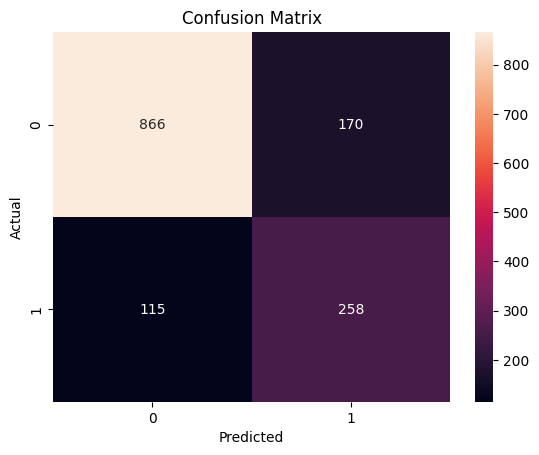

In [31]:
# Visualizing confusion matrix using heatmap for better understanding of model performance

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## FINAL CONCLUSION

* In this project, we successfully built a Logistic Regression model to predict customer churn in a telecom company.
* The dataset was preprocessed by handling missing values, converting data types, encoding categorical variables, scaling numerical features, and addressing class imbalance using SMOTE.
* The final model achieved an accuracy of approximately **79.8%**, demonstrating strong performance in distinguishing between customers who are likely to churn and those who are likely to stay.
* The use of SMOTE helped improve the model's ability to learn patterns from the minority churn class, making the prediction process more balanced and reliable.
* The results show that factors such as contract type, tenure, monthly charges, and payment methods play an important role in customer churn behavior.
* This project demonstrates how Machine Learning can be used to identify at-risk customers, helping businesses take proactive retention measures and reduce customer loss.
* For future improvements, more advanced models such as Random Forest, XGBoost, or Gradient Boosting could be explored, along with hyperparameter tuning, to further improve predictive performance.

Overall, the project successfully demonstrates the practical application of Machine Learning in solving a real-world business problem and supporting data-driven decision-making.
